In [41]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.preprocessing import MinMaxScaler
import torch

# Preprocessing and Feature Engineering

In [3]:
team_regions = pd.read_csv("Team Region Groups - Sheet1.csv")
data_dict = pd.read_csv("DataDictionary - Sheet1.csv")
regional_games = pd.read_csv("East Regional Games to predict - Sheet1.csv")
pd.set_option('display.max_columns', None)
games_2022 = pd.read_csv('games_2022 (edited) - games_2022.csv')
games_2022

,game_id,game_date,team,FGA_2,FGM_2,FGA_3,FGM_3,FTA,FTM,AST,BLK,STL,TOV,TOV_team,DREB,OREB,F_tech,F_personal,team_score,opponent_team_score,largest_lead,OT_length_min_tot,rest_days,attendance,tz_dif_H_E,prev_game_dist,home_away_NS,travel_dist,home_away
0,game_2022_2011,2021-12-30,georgia_lady_bulldogs,50,22,11,5,6,3,14,7,7,18,0,25,11,0,18,62,68,1,0,9,3241.0,0,0,1,0,home
1,game_2022_2011,2021-12-30,lsu_tigers,50,24,11,4,15,8,15,2,15,14,2,25,11,0,7,68,62,14,0,3,3241.0,0,824,-1,824,home
2,game_2022_2012,2021-12-30,missouri_tigers,43,18,15,7,16,13,10,1,4,8,1,31,6,0,11,70,69,8,5,8,6139.0,0,371,1,0,away
3,game_2022_2012,2021-12-30,south_carolina_gamecocks,55,23,21,6,9,5,15,8,3,8,0,27,20,0,15,69,70,6,5,9,6139.0,0,1154,-1,1154,home
4,game_2022_2013,2021-12-30,tennessee_lady_volunteers,41,20,15,4,15,10,16,8,5,15,1,34,12,0,13,62,44,19,0,3,8124.0,0,0,1,0,home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9821,game_2022_4795,2022-03-01,xavier_musketeers,44,19,12,2,12,9,15,3,4,10,0,25,8,0,12,53,74,0,0,2,156.0,0,0,1,0,home
9822,game_2022_4968,2022-03-04,harvard_crimson,30,19,39,15,10,2,20,2,13,6,0,28,10,0,8,85,52,40,0,13,373.0,0,378,-1,173,home
9823,game_2022_4968,2022-03-04,dartmouth_big_green,32,15,26,6,7,4,7,1,4,21,2,29,10,0,8,52,85,3,0,6,373.0,0,479,1,0,home
9824,game_2022_5067,2022-03-06,harvard_crimson,38,13,35,6,10,9,11,3,7,11,0,23,18,0,20,53,73,0,0,2,757.0,0,173,1,0,home


In [4]:
games_2022['team'].nunique()

355

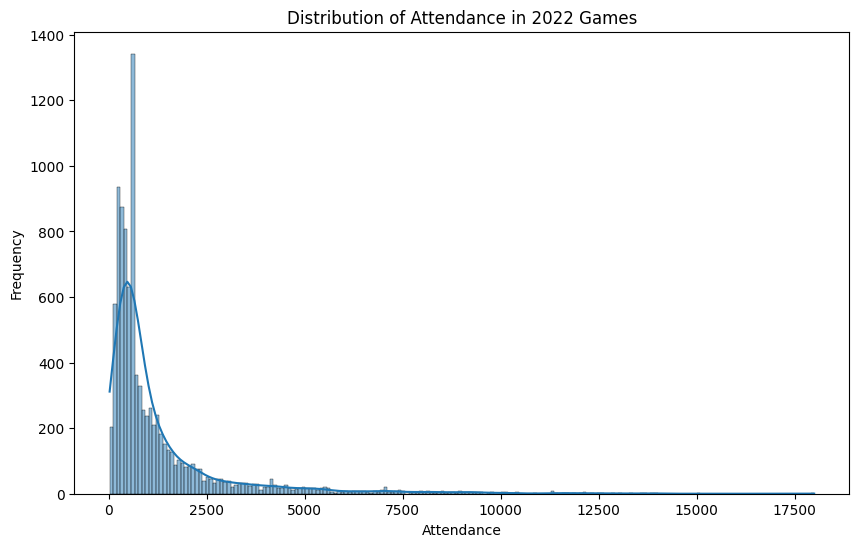

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(games_2022["attendance"], kde=True)
plt.title("Distribution of Attendance in 2022 Games")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()

In [7]:
#log normalize

columns_to_transform = [
    'BLK',
    'TOV_team',
    'largest_lead',
    'rest_days',
    'attendance',
    'travel_dist',
    'prev_game_dist'
]

for col in columns_to_transform:
    games_2022[col] = np.log1p(games_2022[col])

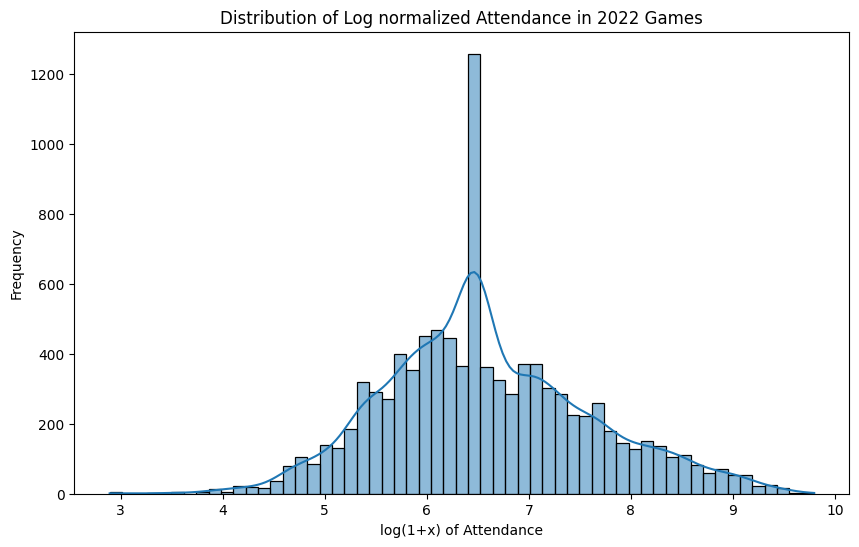

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(games_2022["attendance"], kde=True)
plt.title("Distribution of Log normalized Attendance in 2022 Games")
plt.xlabel("log(1+x) of Attendance")
plt.ylabel("Frequency")
plt.show()

In [9]:
#normalize between 0 and 1

columns_to_normalize = [
    'AST',
    'BLK',
    'STL',
    'TOV',
    'TOV_team',
    'DREB',
    'OREB',
    'F_personal',
    'F_tech',
    'team_score',
    'opponent_team_score',
    'OT_length_min_tot',
    'largest_lead',
    'rest_days',
    'attendance',
    'tz_dif_H_E',
    'prev_game_dist',
    'travel_dist']

scaler = MinMaxScaler(feature_range=(0, 1))
games_2022[columns_to_normalize] = scaler.fit_transform(games_2022[columns_to_normalize])

In [10]:
games_2022["fg_pct_2"] = games_2022["FGM_2"] / games_2022["FGA_2"]
games_2022["fg_pct_3"] = games_2022["FGM_3"] / games_2022["FGA_3"]
games_2022["ft_pct"] = games_2022["FTM"] / games_2022["FTA"]

In [11]:
games_2022["point_diff"] = games_2022["team_score"] - games_2022["opponent_team_score"]

games_2022["win"] = (games_2022["team_score"] > games_2022["opponent_team_score"]).astype(int)

In [12]:
team_agg = games_2022.groupby("team").agg({
    "win": ["mean", "sum"],
    "team_score": "mean",
    "opponent_team_score": "mean",
    "fg_pct_2": "mean",
    "fg_pct_3": "mean",
    "ft_pct": "mean",
    "AST": "mean",
    "BLK": "mean",
    "STL": "mean",
    "TOV": "mean",
    "TOV_team": "mean",
    "DREB": "mean",
    "OREB": "mean",
    "F_personal": "mean",
    "F_tech": "mean",
    "OT_length_min_tot": "mean",
    "largest_lead": "mean",
    "rest_days": "mean",
    "attendance": "mean",
    "tz_dif_H_E": "mean",
    "prev_game_dist": "mean",
    "travel_dist": "mean",
    "point_diff": "mean"
})

In [13]:
team_agg.columns = ["_".join(col).strip() for col in team_agg.columns.values]
team_agg = team_agg.reset_index()
team_agg.rename(columns={"win_mean": "win_percentage", "win_sum": "total_wins"}, inplace=True)
team_agg = team_agg.merge(team_regions, on="team", how="left")

In [14]:
all_teams = pd.concat([games_2022["team"], games_2022["team"]]).unique()
elo_ratings = {team: 1500 for team in all_teams}

In [15]:
def expected_score(rating_a, rating_b):
    """Calculate expected score for team A against team B."""
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

In [16]:
grouped_games = games_2022.groupby("game_id")
k = 20

In [17]:
for game_id, group in grouped_games:
    if group.shape[0] != 2:
        continue
    if "home" in group["home_away"].values and "away" in group["home_away"].values:
        home_row = group[group["home_away"] == "home"].iloc[0]
        away_row = group[group["home_away"] == "away"].iloc[0]
    else:
        home_row = group.iloc[0]
        away_row = group.iloc[1]

    home_team = home_row["team"]
    away_team = away_row["team"]
    home_score = home_row["team_score"]
    away_score = away_row["team_score"]

    outcome_home = 1 if home_score > away_score else 0
    outcome_away = 1 - outcome_home

    expected_home = expected_score(elo_ratings[home_team], elo_ratings[away_team])
    expected_away = expected_score(elo_ratings[away_team], elo_ratings[home_team])

    elo_ratings[home_team] += k * (outcome_home - expected_home)
    elo_ratings[away_team] += k * (outcome_away - expected_away)

In [18]:
team_agg["elo_rating"] = team_agg["team"].apply(lambda t: elo_ratings.get(t, 1500))

In [19]:
regional_games["elo_home"] = regional_games["team_home"].apply(lambda t: elo_ratings.get(t, 1500))
regional_games["elo_away"] = regional_games["team_away"].apply(lambda t: elo_ratings.get(t, 1500))
regional_games["expected_home"] = 1 / (1 + 10 ** ((regional_games["elo_away"] - regional_games["elo_home"]) / 400))
regional_games["predicted_winning_%_elo"] = regional_games["expected_home"]

In [20]:
team_agg["combined_rank_score"] = team_agg["win_percentage"] * 0.5 + (team_agg["elo_rating"] / 3000) * 0.5
team_agg.sort_values("combined_rank_score", ascending=False, inplace=True)

In [21]:
games_home = games_2022[games_2022["home_away"] == "home"][["game_id", "team", "win"]].rename(columns={"team": "team_home", "win": "win_home"})
games_away = games_2022[games_2022["home_away"] == "away"][["game_id", "team", "win"]].rename(columns={"team": "team_away", "win": "win_away"})

In [22]:
team_agg

,team,win_percentage,total_wins,team_score_mean,opponent_team_score_mean,fg_pct_2_mean,fg_pct_3_mean,ft_pct_mean,AST_mean,BLK_mean,STL_mean,TOV_mean,TOV_team_mean,DREB_mean,OREB_mean,F_personal_mean,F_tech_mean,OT_length_min_tot_mean,largest_lead_mean,rest_days_mean,attendance_mean,tz_dif_H_E_mean,prev_game_dist_mean,travel_dist_mean,point_diff_mean,region,elo_rating,combined_rank_score
262,south_carolina_gamecocks,0.935484,29,0.441966,0.258667,0.476529,0.315578,0.676142,0.366487,0.712499,0.232975,0.308419,0.202061,0.563275,0.521169,0.312175,0.000000,0.010753,0.683199,0.394258,0.831776,0.467742,0.496808,0.408745,0.183298,North,1707.349408,0.752300
85,florida_gulf_coast_eagles,0.923077,24,0.485262,0.322070,0.574094,0.333584,0.643437,0.439103,0.474550,0.353276,0.224203,0.278662,0.420118,0.268029,0.357320,0.000000,0.000000,0.659617,0.410602,0.560688,0.500000,0.508339,0.371911,0.163192,North,1671.877632,0.740185
182,nc_state_wolfpack,0.906250,29,0.489486,0.308703,0.508094,0.367841,0.767493,0.368056,0.418930,0.269676,0.250762,0.068680,0.542468,0.375000,0.296371,0.018750,0.020833,0.652206,0.387569,0.747550,0.479167,0.403998,0.304096,0.180783,NaN,1710.561783,0.738219
278,stanford_cardinal,0.903226,28,0.465179,0.307205,0.500605,0.358444,0.673766,0.392473,0.631627,0.318996,0.268293,0.192523,0.491315,0.417339,0.386056,0.000000,0.000000,0.640675,0.378475,0.673757,0.483871,0.415306,0.420103,0.157974,West,1699.737450,0.734902
307,ucf_knights,0.888889,24,0.342679,0.219453,0.438113,0.307366,0.701903,0.349794,0.462390,0.417010,0.334237,0.268341,0.376068,0.429398,0.311828,0.007407,0.000000,0.580225,0.417590,0.611184,0.456790,0.575950,0.440928,0.123226,North,1668.665847,0.722555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,detroit_mercy_titans,0.037037,1,0.292835,0.418830,0.407079,0.262656,0.655214,0.276749,0.373759,0.334705,0.433604,0.181466,0.385565,0.358796,0.446834,0.014815,0.012346,0.208712,0.398821,0.416309,0.500000,0.417984,0.315842,-0.125995,NaN,1319.290953,0.238400
31,butler_bulldogs,0.035714,1,0.295060,0.503672,0.474366,0.261624,0.689546,0.288690,0.310307,0.182540,0.435540,0.296922,0.386447,0.290179,0.335253,0.000000,0.035714,0.203671,0.403987,0.516992,0.500000,0.413786,0.255909,-0.208611,NaN,1318.480270,0.237604
311,ul_monroe_warhawks,0.000000,0,0.304163,0.461342,0.386973,0.231866,0.669633,0.241162,0.394936,0.306397,0.385809,0.295437,0.334499,0.403409,0.486804,0.027273,0.015152,0.227693,0.426300,0.493391,0.492424,0.459042,0.315611,-0.157179,NaN,1331.890491,0.221982
64,delaware_state_hornets,0.000000,0,0.209856,0.490229,0.386449,0.233655,0.659957,0.188131,0.256635,0.161616,0.493348,0.485209,0.399767,0.291193,0.275660,0.045455,0.015152,0.159871,0.425030,0.449940,0.500000,0.511729,0.355291,-0.280374,NaN,1329.466526,0.221578


In [23]:
matchups = pd.merge(games_home, games_away, on="game_id")

features = ['win_percentage', 'team_score_mean', 'fg_pct_2_mean', 'fg_pct_3_mean',
            'ft_pct_mean', 'AST_mean', 'BLK_mean', 'STL_mean', 'TOV_mean', 'point_diff_mean', 'elo_rating']

In [24]:
matchups = matchups.merge(team_agg[['team'] + features], left_on='team_home', right_on='team', how='left') \
                   .drop("team", axis=1) \
                   .rename(columns={f: f"{f}_home" for f in features})

matchups = matchups.merge(team_agg[['team'] + features], left_on='team_away', right_on='team', how='left') \
                   .drop("team", axis=1) \
                   .rename(columns={f: f"{f}_away" for f in features})

In [25]:
for f in features:
    matchups[f + "_diff"] = matchups[f + "_home"] - matchups[f + "_away"]

In [26]:
X = matchups[[f + "_diff" for f in features]]
y = matchups["win_home"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
matchups

,game_id,team_home,win_home,team_away,win_away,win_percentage_home,team_score_mean_home,fg_pct_2_mean_home,fg_pct_3_mean_home,ft_pct_mean_home,AST_mean_home,BLK_mean_home,STL_mean_home,TOV_mean_home,point_diff_mean_home,elo_rating_home,win_percentage_away,team_score_mean_away,fg_pct_2_mean_away,fg_pct_3_mean_away,ft_pct_mean_away,AST_mean_away,BLK_mean_away,STL_mean_away,TOV_mean_away,point_diff_mean_away,elo_rating_away,win_percentage_diff,team_score_mean_diff,fg_pct_2_mean_diff,fg_pct_3_mean_diff,ft_pct_mean_diff,AST_mean_diff,BLK_mean_diff,STL_mean_diff,TOV_mean_diff,point_diff_mean_diff,elo_rating_diff
0,game_2022_2012,south_carolina_gamecocks,0,missouri_tigers,1,0.935484,0.441966,0.476529,0.315578,0.676142,0.366487,0.712499,0.232975,0.308419,0.183298,1707.349408,0.600000,0.432710,0.495239,0.372334,0.733970,0.345370,0.314494,0.206173,0.310569,0.031464,1558.831125,0.335484,0.009255,-0.018710,-0.056755,-0.057828,0.021117,0.398005,0.026802,-0.002151,0.151834,148.518283
1,game_2022_2013,tennessee_lady_volunteers,1,alabama_crimson_tide,0,0.741935,0.429304,0.451456,0.298011,0.635182,0.379032,0.619714,0.232975,0.370574,0.091046,1612.607377,0.566667,0.434891,0.467527,0.335122,0.708576,0.283333,0.434958,0.329630,0.321951,0.050467,1538.504564,0.175269,-0.005587,-0.016071,-0.037111,-0.073394,0.095699,0.184756,-0.096655,0.048623,0.040579,74.102812
2,game_2022_2111,auburn_tigers,0,alabama_crimson_tide,1,0.357143,0.371162,0.420752,0.279180,0.651444,0.283730,0.470657,0.313492,0.316202,-0.020360,1452.245432,0.566667,0.434891,0.467527,0.335122,0.708576,0.283333,0.434958,0.329630,0.321951,0.050467,1538.504564,-0.209524,-0.063729,-0.046775,-0.055941,-0.057131,0.000397,0.035699,-0.016138,-0.005749,-0.070828,-86.259132
3,game_2022_2112,tennessee_lady_volunteers,1,arkansas_razorbacks,0,0.741935,0.429304,0.451456,0.298011,0.635182,0.379032,0.619714,0.232975,0.370574,0.091046,1612.607377,0.580645,0.464878,0.467804,0.323014,0.676956,0.326165,0.571328,0.272401,0.226593,0.075068,1547.065532,0.161290,-0.035574,-0.016348,-0.025003,-0.041774,0.052867,0.048386,-0.039427,0.143981,0.015978,65.541845
4,game_2022_2113,georgia_lady_bulldogs,1,florida_gators,0,0.678571,0.422897,0.461190,0.313506,0.739002,0.425595,0.640540,0.317460,0.344077,0.094793,1590.213184,0.677419,0.416039,0.449667,0.302377,0.733578,0.322581,0.442159,0.328554,0.361133,0.036479,1590.688094,0.001152,0.006859,0.011524,0.011128,0.005424,0.103015,0.198382,-0.011094,-0.017056,0.058314,-0.474910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,game_2022_4442,detroit_mercy_titans,0,cleveland_state_vikings,1,0.037037,0.292835,0.407079,0.262656,0.655214,0.276749,0.373759,0.334705,0.433604,-0.125995,1319.290953,0.680000,0.410467,0.443847,0.300088,0.702101,0.278889,0.497782,0.348148,0.356098,0.068411,1563.999231,-0.642963,-0.117632,-0.036768,-0.037433,-0.046886,-0.002140,-0.124024,-0.013443,0.077507,-0.194406,-244.708278
2510,game_2022_4859,binghamton_bearcats,1,umbc_retrievers,0,0.269231,0.303379,0.443587,0.278234,0.739119,0.302350,0.407946,0.245014,0.337711,-0.023724,1404.660065,0.080000,0.272150,0.393031,0.297315,0.710628,0.236667,0.180511,0.287407,0.362927,-0.126355,1340.586805,0.189231,0.031229,0.050556,-0.019081,0.028492,0.065684,0.227435,-0.042393,-0.025216,0.102631,64.073260
2511,game_2022_4786,western_illinois_leathernecks,0,south_dakota_coyotes,1,0.444444,0.414330,0.478781,0.311097,0.635103,0.316872,0.461720,0.285322,0.311653,-0.049152,1479.599207,0.827586,0.423783,0.492593,0.331312,0.750942,0.362069,0.467719,0.329502,0.202691,0.146310,1624.175728,-0.383142,-0.009453,-0.013812,-0.020215,-0.115839,-0.045197,-0.005999,-0.044180,0.108962,-0.195462,-144.576521
2512,game_2022_4795,xavier_musketeers,0,seton_hall_pirates,1,0.300000,0.358255,0.419886,0.261187,0.734109,0.329630,0.399384,0.277778,0.350407,-0.098131,1411.287579,0.612903,0.423274,0.462575,0.337344,0.761860,0.400538,0.464570,

# XGBoost For Winning Probability Prediction

In [33]:
# Hyperparmeter tuning

xgb_model = xgb.XGBClassifier(objective='binary:logistic', booster='gbtree', seed=42)

param_grid = {
    'learning_rate': [0.1, 0.3],
    'max_depth': [5, 9],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.5, 0.8],
    'n_estimators': [100, 150]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='roc_auc', cv=3, verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best auc:", grid_search.best_score_)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.6}
Best auc: 0.8375298651638919


In [34]:
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.1,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_test, label=y_test)

evals = [(dtrain, 'train'), (dval, 'eval')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=evals,
    early_stopping_rounds=10, # pruning
    verbose_eval=True
)

[0]	train-auc:0.86974	eval-auc:0.85676
[1]	train-auc:0.89325	eval-auc:0.87434
[2]	train-auc:0.89646	eval-auc:0.87907
[3]	train-auc:0.89967	eval-auc:0.88147
[4]	train-auc:0.90155	eval-auc:0.87886
[5]	train-auc:0.90453	eval-auc:0.87930
[6]	train-auc:0.90658	eval-auc:0.88140
[7]	train-auc:0.90763	eval-auc:0.87985
[8]	train-auc:0.90814	eval-auc:0.88059
[9]	train-auc:0.90948	eval-auc:0.88042
[10]	train-auc:0.91063	eval-auc:0.88026
[11]	train-auc:0.91205	eval-auc:0.88016
[12]	train-auc:0.91251	eval-auc:0.88104
[13]	train-auc:0.91365	eval-auc:0.88043


In [58]:
dtest = xgb.DMatrix(X_test)

y_pred_prob = model.predict(dtest)
y_pred = (y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)

auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")

Accuracy: 0.8032
AUC: 0.8804


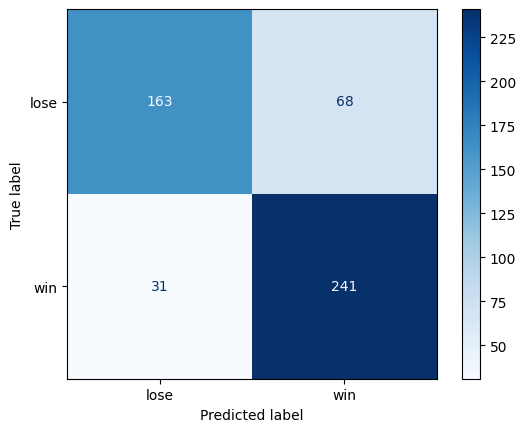

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d",
    display_labels=["lose", "win"]
)

In [39]:
importance = model.get_score(importance_type='gain')
importance

{'win_percentage_diff': 19.300548553466797,
 'team_score_mean_diff': 3.539820671081543,
 'fg_pct_2_mean_diff': 2.833904504776001,
 'fg_pct_3_mean_diff': 3.1168906688690186,
 'ft_pct_mean_diff': 3.804534912109375,
 'AST_mean_diff': 3.7206435203552246,
 'BLK_mean_diff': 2.9173696041107178,
 'STL_mean_diff': 2.853879690170288,
 'TOV_mean_diff': 3.294581174850464,
 'point_diff_mean_diff': 29.547000885009766,
 'elo_rating_diff': 41.99172592163086}

In [42]:
y_pred_prob = model.predict(dval)
y_pred = (y_pred_prob > 0.5).astype(int)

f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Recall Score: {recall:.4f}")


F1 Score: 0.8296
Recall Score: 0.8860


# Final Predictions

In [43]:
regional_games = regional_games.merge(team_agg[['team'] + features], left_on='team_home', right_on='team', how='left') \
                               .drop("team", axis=1) \
                               .rename(columns={f: f"{f}_home" for f in features})
regional_games = regional_games.merge(team_agg[['team'] + features], left_on='team_away', right_on='team', how='left') \
                               .drop("team", axis=1) \
                               .rename(columns={f: f"{f}_away" for f in features})

In [44]:
for f in features:
    regional_games[f+ "_diff"] = regional_games[f + "_home"] - regional_games[f + "_away"]

In [56]:
predictor_cols = [f + "_diff" for f in features]
dregional = xgb.DMatrix(regional_games[predictor_cols], feature_names=predictor_cols)

final_predictions = model.predict(dregional)

regional_games["predicted_prob_model"] = final_predictions
regional_games[["predicted_prob_model", "team_home", "team_away"]]

,predicted_prob_model,team_home,team_away
0,0.440387,rhode_island_rams,north_carolina_tar_heels
1,0.690749,nc_state_wolfpack,rhode_island_rams
2,0.633938,nc_state_wolfpack,north_carolina_tar_heels
3,0.671101,liberty_flames,bucknell_bison
4,0.639433,drexel_dragons,delaware_blue_hens
5,0.488816,massachusetts_minutewomen,princeton_tigers
6,0.572055,buffalo_bulls,stony_brook_seawolves
7,0.534959,fairfield_stags,towson_tigers
8,0.789622,uconn_huskies,campbell_fighting_camels
9,0.492439,american_university_eagles,columbia_lions


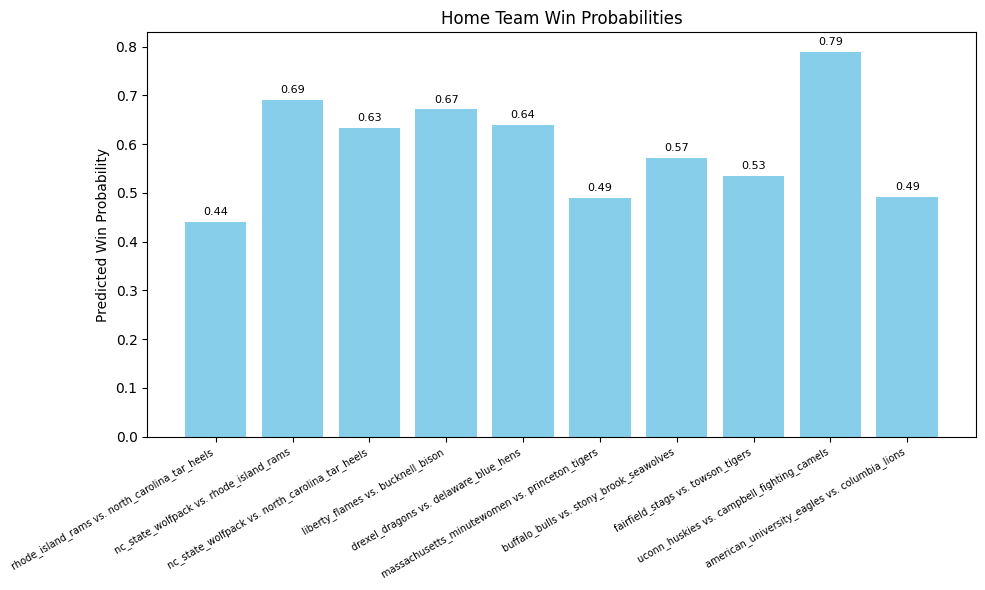

In [57]:
results_df = pd.DataFrame({
    "predicted_prob_model": [
        0.440387, 0.690749, 0.633938, 0.671101, 0.639433,
        0.488816, 0.572055, 0.534959, 0.789622, 0.492439
    ],
    "team_home": [
        "rhode_island_rams vs. north_carolina_tar_heels",
        "nc_state_wolfpack vs. rhode_island_rams",
        "nc_state_wolfpack vs. north_carolina_tar_heels",
        "liberty_flames vs. bucknell_bison",
        "drexel_dragons vs. delaware_blue_hens",
        "massachusetts_minutewomen vs. princeton_tigers",
        "buffalo_bulls vs. stony_brook_seawolves",
        "fairfield_stags vs. towson_tigers",
        "uconn_huskies vs. campbell_fighting_camels",
        "american_university_eagles vs. columbia_lions"
    ]
})

teams = results_df["team_home"]
probs = results_df["predicted_prob_model"]
plt.figure(figsize=(10, 6))
bars = plt.bar(teams, probs, color='skyblue')

# Add probability labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=8
    )
plt.xticks(rotation=30, ha='right', fontsize=7)  # Rotate x-axis labels for readability
plt.ylabel("Predicted Win Probability")
plt.title("Home Team Win Probabilities")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


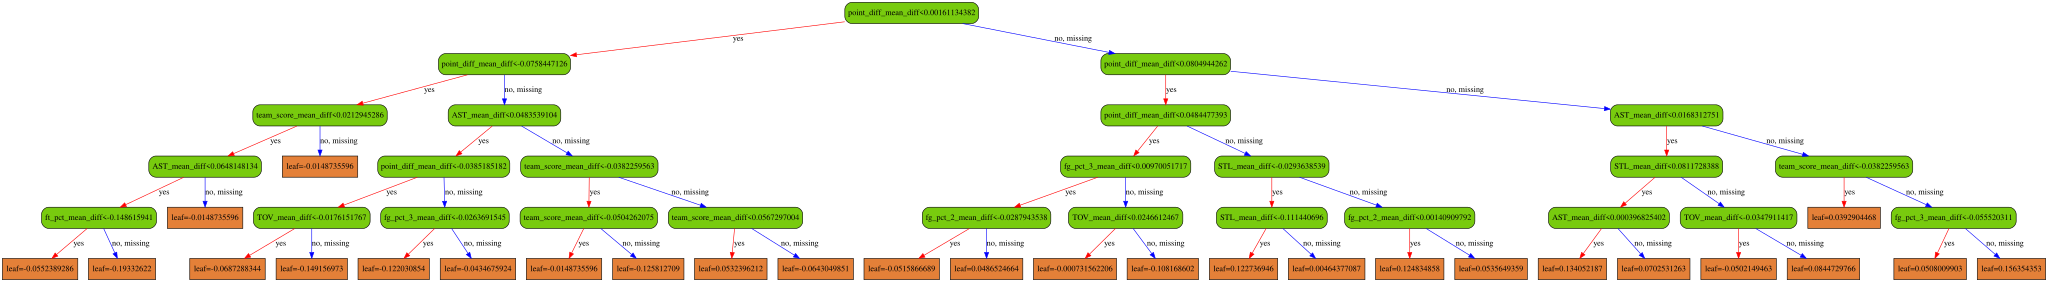

In [59]:
bst = model

node_params = {'shape': 'box',
              'style': 'filled, rounded',
              'fillcolor': '#78cbe'}

leaf_params = {'shape': 'box',
              'style': 'filled',
              'fillcolor': '#e48038'}

xgb.to_graphviz(model, num_trees=0, size="10,10",
               condition_node_params=node_params,
               leaf_node_params=leaf_params

               )

# Ranking With K-mean Clustering

In [60]:
team_agg.drop(columns=['opponent_team_score_mean', 'TOV_mean', 'TOV_team_mean', 'OT_length_min_tot_mean', 'rest_days_mean', 'tz_dif_H_E_mean', 'prev_game_dist_mean', 'travel_dist_mean', 'point_diff_mean', 'region'], inplace=True)

In [61]:
ranking = pd.merge(team_regions, team_agg, on=['team'], how='left')
ranking = ranking[~(ranking['win_percentage'].isna())]

features_to_scale = ['total_wins', 'elo_rating']
scaler = MinMaxScaler(feature_range=(0, 1))
ranking[features_to_scale] = scaler.fit_transform(ranking[features_to_scale])
ranking

,team,region,win_percentage,total_wins,team_score_mean,fg_pct_2_mean,fg_pct_3_mean,ft_pct_mean,AST_mean,BLK_mean,STL_mean,DREB_mean,OREB_mean,F_personal_mean,F_tech_mean,largest_lead_mean,attendance_mean,elo_rating,combined_rank_score
0,alabama_crimson_tide,North,0.566667,0.294118,0.434891,0.467527,0.335122,0.708576,0.283333,0.434958,0.329630,0.417949,0.376042,0.416129,0.020000,0.511084,0.705633,0.250511,0.539751
1,alabama_state_lady_hornets,North,0.481481,0.058824,0.365178,0.406138,0.289688,0.678347,0.344650,0.515411,0.255144,0.420703,0.442130,0.559140,0.051852,0.391858,0.531854,0.000000,0.487752
2,arkansas_razorbacks,North,0.580645,0.352941,0.464878,0.467804,0.323014,0.676956,0.326165,0.571328,0.272401,0.456576,0.346774,0.401665,0.012903,0.507477,0.718469,0.288512,0.548167
3,belmont_bruins,North,0.758621,0.588235,0.425073,0.512895,0.329089,0.692107,0.402299,0.496145,0.330779,0.385500,0.344828,0.344828,0.000000,0.584885,0.579638,0.587705,0.648388
4,charleston_cougars,North,0.535714,0.176471,0.453271,0.446814,0.286593,0.760101,0.345238,0.497138,0.386243,0.379121,0.440848,0.369816,0.014286,0.473581,0.424833,0.134492,0.519918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,ut_arlington_mavericks,West,0.740741,0.470588,0.429560,0.476585,0.272106,0.690607,0.404321,0.477238,0.293553,0.463438,0.335648,0.400239,0.014815,0.533610,0.540811,0.569349,0.638759
135,utah_utes,West,0.645161,0.470588,0.486283,0.494864,0.346593,0.784853,0.396057,0.385041,0.253286,0.425145,0.417339,0.405827,0.064516,0.537464,0.684906,0.453177,0.586608
136,utah_valley_wolverines,West,0.482759,0.117647,0.359974,0.482994,0.301357,0.785739,0.379310,0.365544,0.197957,0.485411,0.325431,0.369299,0.020690,0.468169,0.526116,0.101047,0.492185
137,washington_state_cougars,West,0.655172,0.411765,0.343539,0.425022,0.332651,0.695577,0.342912,0.519461,0.292465,0.381963,0.349138,0.372636,0.034483,0.480665,0.597482,0.435254,0.590940


In [62]:
ranking.columns

Index(['team', 'region', 'win_percentage', 'total_wins', 'team_score_mean',
       'fg_pct_2_mean', 'fg_pct_3_mean', 'ft_pct_mean', 'AST_mean', 'BLK_mean',
       'STL_mean', 'DREB_mean', 'OREB_mean', 'F_personal_mean', 'F_tech_mean',
       'largest_lead_mean', 'attendance_mean', 'elo_rating',
       'combined_rank_score'],
      dtype='object')

In [68]:
ranking_north = ranking[ranking['region'] == 'North']

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

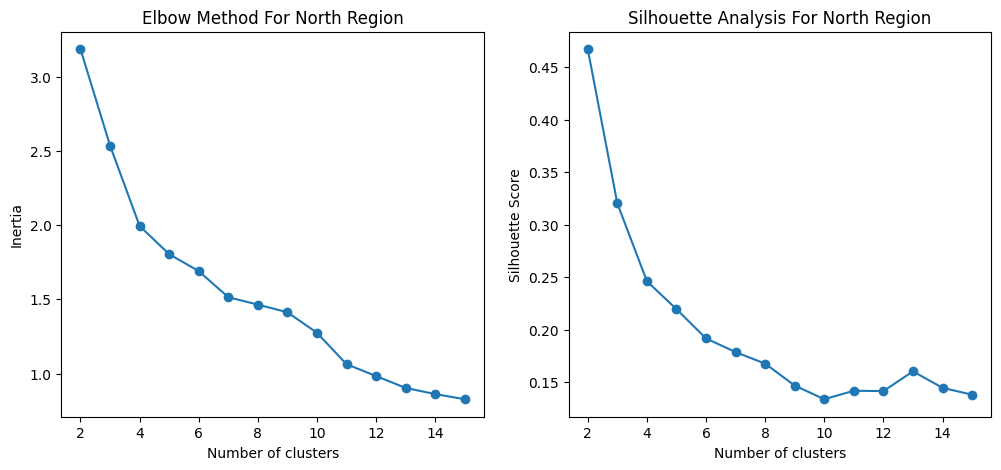

In [65]:
df = ranking_north

features_scaled = df[['win_percentage', 'total_wins', 'team_score_mean',
       'fg_pct_2_mean', 'fg_pct_3_mean', 'ft_pct_mean', 'AST_mean', 'BLK_mean',
       'STL_mean', 'DREB_mean', 'OREB_mean',
       'largest_lead_mean', 'elo_rating',
       'combined_rank_score']]

features = df.drop(columns=['team', 'region'])

inertia = []
silhouette = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(features_scaled, kmeans.labels_)
    silhouette.append(score)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For North Region')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis For North Region')
plt.show()


In [66]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(features_scaled)
centroids = kmeans.cluster_centers_

# Rank clusters by their centroids
# Sum the centroid values to get a single score per cluster.
cluster_scores = {}
for i in range(n_clusters):
    cluster_scores[i] = np.sum(centroids[i])

# Order clusters from best to worst (highest summed value is best)
sorted_clusters = sorted(cluster_scores.items(), key=lambda x: x[1], reverse=True)
print("Cluster ranking based on centroids (best to worst):")
for rank, (cluster_label, score) in enumerate(sorted_clusters, 1):
    print(f"Rank {rank}: Cluster {cluster_label} with score {score:.2f}")

# Create a mapping from cluster label to overall cluster rank
cluster_order = {cluster_label: rank for rank, (cluster_label, _) in enumerate(sorted_clusters, 1)}
df['cluster_order'] = df['cluster'].map(cluster_order)

# Compute distance of each team (in scaled space) to its cluster centroid
scaled_df = pd.DataFrame(features_scaled)
df['distance'] = [
    np.linalg.norm(scaled_df.iloc[i].values - centroids[cluster])
    for i, cluster in enumerate(df['cluster'])
]

# Within each cluster, rank teams based on distance (lower distance = closer to the centroid)
df['within_cluster_rank'] = df.groupby('cluster')['distance'].rank(method='first', ascending=True)

# Sort teams first by the cluster rank (best clusters first) then by within-cluster ranking
df_sorted = df.sort_values(by=['cluster_order', 'within_cluster_rank'])

print("\nFinal Team Rankings:")
print(df_sorted[['team', 'cluster', 'cluster_order', 'distance', 'within_cluster_rank']])

Cluster ranking based on centroids (best to worst):
Rank 1: Cluster 1 with score 7.71
Rank 2: Cluster 2 with score 6.98
Rank 3: Cluster 3 with score 5.99
Rank 4: Cluster 0 with score 5.42

Final Team Rankings:
                               team  cluster  cluster_order  distance  \
46                      ucf_knights        1              1  0.179738   
39       stephen_f_austin_ladyjacks        1              1  0.197239   
26                       lsu_tigers        1              1  0.211708   
9         florida_gulf_coast_eagles        1              1  0.228877   
37              south_florida_bulls        1              1  0.241220   
35         south_carolina_gamecocks        1              1  0.445773   
31                  ole_miss_rebels        2              2  0.117894   
8                    florida_gators        2              2  0.154463   
5                   charlotte_49ers        2              2  0.158938   
44                tulane_green_wave        2              2 

/tmp/ipython-input-3437717245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = kmeans.fit_predict(features_scaled)
/tmp/ipython-input-3437717245.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_order'] = df['cluster'].map(cluster_order)
/tmp/ipython-input-3437717245.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

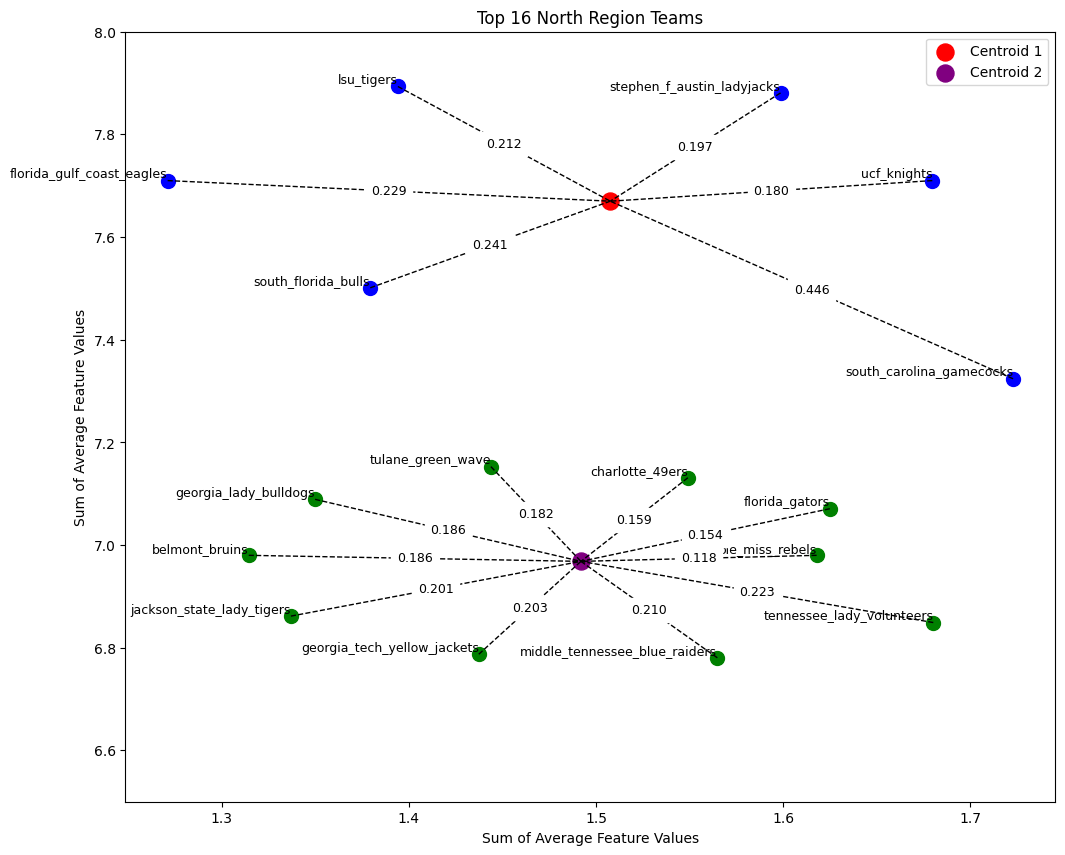

In [67]:
centroid1 = np.array([1.5, 7.71])  # Centroid 1 for cluster 1 with y = 7.71
centroid2 = np.array([1.5, 6.98])  # Centroid 2 for cluster 2 with y = 6.98

cluster1_teams = {
    "ucf_knights": 0.179738,
    "stephen_f_austin_ladyjacks": 0.197239,
    "lsu_tigers": 0.211708,
    "florida_gulf_coast_eagles": 0.228877,
    "south_florida_bulls": 0.241220,
    "south_carolina_gamecocks": 0.445773
}

cluster2_teams = {
    "ole_miss_rebels": 0.117894,
    "florida_gators": 0.154463,
    "charlotte_49ers": 0.158938,
    "tulane_green_wave": 0.181696,
    "georgia_lady_bulldogs": 0.185529,
    "belmont_bruins": 0.185529,
    "jackson_state_lady_tigers": 0.201486,
    "georgia_tech_yellow_jackets": 0.202629,
    "middle_tennessee_blue_raiders": 0.209884,
    "tennessee_lady_volunteers": 0.222797
}

# Function to generate approximate 2D coordinates around a centroid using distance and random angle
def generate_points_around_centroid(centroid, distances, num_points):
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for i, (team, dist) in enumerate(distances.items()):
        x = centroid[0] + dist * np.cos(angles[i % len(angles)])
        y = centroid[1] + dist * np.sin(angles[i % len(angles)])
        points.append((team, np.array([x, y]), dist))
    return points

# Generate points for clusters
cluster1_points = generate_points_around_centroid(centroid1, cluster1_teams, len(cluster1_teams))
cluster2_points = generate_points_around_centroid(centroid2, cluster2_teams, len(cluster2_teams))

# Extract coordinates and team names
cluster1_coords = np.array([pt[1] for pt in cluster1_points])
cluster1_names = [pt[0] for pt in cluster1_points]
cluster1_distances = [pt[2] for pt in cluster1_points]

cluster2_coords = np.array([pt[1] for pt in cluster2_points])
cluster2_names = [pt[0] for pt in cluster2_points]
cluster2_distances = [pt[2] for pt in cluster2_points]

# Compute centroids
centroid1_actual = np.mean(cluster1_coords, axis=0)
centroid2_actual = np.mean(cluster2_coords, axis=0)

# Plot the data points for clusters with team names as labels
plt.figure(figsize=(12, 10))
for (x, y), name, dist in zip(cluster1_coords, cluster1_names, cluster1_distances):
    plt.scatter(x, y, color='blue', s=100)
    plt.text(x, y, name, fontsize=9, ha='right', va='bottom')
    plt.plot([x, centroid1_actual[0]], [y, centroid1_actual[1]], 'k--', lw=1)
    plt.text((x + centroid1_actual[0]) / 2, (y + centroid1_actual[1]) / 2, f"{dist:.3f}", fontsize=9, ha='center', va='center', backgroundcolor='white')

for (x, y), name, dist in zip(cluster2_coords, cluster2_names, cluster2_distances):
    plt.scatter(x, y, color='green', s=100)
    plt.text(x, y, name, fontsize=9, ha='right', va='bottom')
    plt.plot([x, centroid2_actual[0]], [y, centroid2_actual[1]], 'k--', lw=1)
    plt.text((x + centroid2_actual[0]) / 2, (y + centroid2_actual[1]) / 2, f"{dist:.3f}", fontsize=9, ha='center', va='center', backgroundcolor='white')

# Plot the centroids
plt.scatter([centroid1_actual[0]], [centroid1_actual[1]], color='red', label='Centroid 1', s=150)
plt.scatter([centroid2_actual[0]], [centroid2_actual[1]], color='purple', label='Centroid 2', s=150)

plt.xlabel('Sum of Average Feature Values')
plt.ylabel('Sum of Average Feature Values')
plt.title('Top 16 North Region Teams')
plt.legend()
plt.grid(False)
plt.ylim(6.5, 8)
plt.show()


# Illustration of K-means

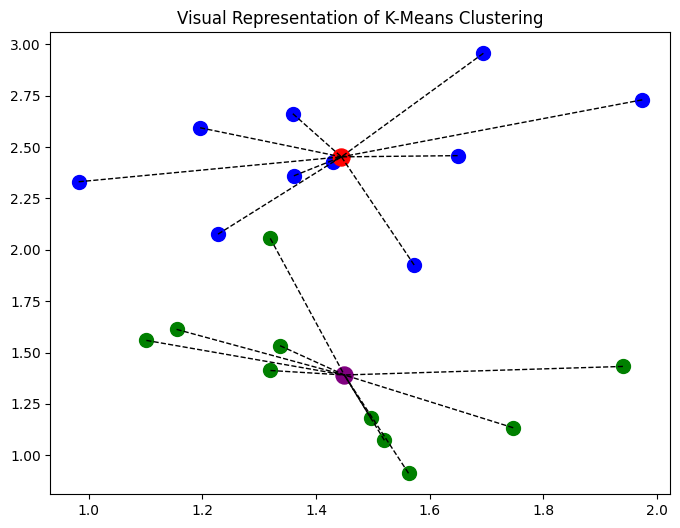

In [69]:
np.random.seed(42)

centroid1_true = np.array([1.5, 2.5])
centroid2_true = np.array([1.5, 1.5])

num_points_per_cluster = 10
noise_scale = 0.3
cluster1 = centroid1_true + noise_scale * np.random.randn(num_points_per_cluster, 2)
cluster2 = centroid2_true + noise_scale * np.random.randn(num_points_per_cluster, 2)

centroid1 = np.mean(cluster1, axis=0)
centroid2 = np.mean(cluster2, axis=0)

distances1 = [np.linalg.norm(pt - centroid1) for pt in cluster1]
distances2 = [np.linalg.norm(pt - centroid2) for pt in cluster2]

# Plot the data points for clusters
plt.figure(figsize=(8, 6))
plt.scatter(cluster1[:, 0], cluster1[:, 1], color='blue', label='Cluster 1 Points', s=100)
plt.scatter(cluster2[:, 0], cluster2[:, 1], color='green', label='Cluster 2 Points', s=100)

# Plot the centroids
plt.scatter([centroid1[0]], [centroid1[1]], color='red', label='Centroid 1', s=150)
plt.scatter([centroid2[0]], [centroid2[1]], color='purple', label='Centroid 2', s=150)

# For cluster 1
for pt, d in zip(cluster1, distances1):
    plt.plot([pt[0], centroid1[0]], [pt[1], centroid1[1]], 'k--', lw=1)
    mid_x, mid_y = (pt[0] + centroid1[0]) / 2, (pt[1] + centroid1[1]) / 2

# For cluster 2
for pt, d in zip(cluster2, distances2):
    plt.plot([pt[0], centroid2[0]], [pt[1], centroid2[1]], 'k--', lw=1)
    mid_x, mid_y = (pt[0] + centroid2[0]) / 2, (pt[1] + centroid2[1]) / 2

plt.title('Visual Representation of K-Means Clustering')
plt.grid(False)
plt.show()